# Final Model

This notebook constructs the final model we will use to find the relative premium for houses in each neghborhood of Chicago. Our final model is an XGBoost regressor.

In [34]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

In [25]:
data = pd.read_parquet(r"..\Data\sale_and_crime_data\chicago_sales_with_crime.parquet")

There are several features in our final data set which we will want to exclude. These include features which encode the relative location of the houses, since we want all of the contribution of the location to be concentrated in the community area feature. We also exclude variables which have little to no predictive value and those which are mostly missing. We point the reader to the Exploring Alternate Linear Regression Models notebook in the data folder for more information.

In [26]:
features_to_exclude = ["pin","is_multisale",'flood_fema_sfha', "sale_filter_same_sale_within_365", "sale_filter_less_than_10k", "single_v_multi_family", "zip_code",
                      "longitude", "latitude", "sale_date_parsed", "class", 'centroid_x_crs_3435', 'centroid_y_crs_3435', 'pin10', 'nearest_metra_route_dist_ft', 'nearest_new_construction_pin10',
                       "school_elementary_district_name",'nearest_golf_course_dist_ft', "school_secondary_district_name", "township_code",  "neighborhood_code",'sale_filter_deed_type', 'nearest_cta_route_dist_ft',
                                 'nearest_vacant_land_pin10','airport_noise_dnl','attic_finish','census_acs5_tract_geoid', 'nearest_neighbor_1_pin10','nearest_neighbor_2_pin10','nearest_neighbor_3_pin10','sale_date_parsed','sale_date', 'sale_year']
data = data.drop(columns = features_to_exclude)

In [27]:
cat_cols = ["type_of_residence", "construction_quality", "garage_size",
            "basement_type", "ext_wall_material", "repair_condition", "basement_finish",
            "central_heating", "central_air", "community_area"]

for col in cat_cols:
    data[col] = data[col].astype("category")

We now run some tests to find the best value for the number of estimators to use in our XGB model.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

y=data["sale_price"]
features = list(data.columns)
features.remove("sale_price")
X=data[features]
model = xgb.XGBRegressor(n_estimators=574, max_depth=5, learning_rate=0.1, random_state=42, enable_categorical=True, tree_method="hist")

# --- 1. Split: train / dev / test (e.g. 70/15/15) ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42
    # 0.1765 * 0.85 ≈ 0.15 → so final split is ~70/15/15
)

print(f"Train: {len(X_train)}, Dev: {len(X_dev)}, Test: {len(X_test)}")

# --- 2. Fit with a large n_estimators + early stopping on dev set ---
model = xgb.XGBRegressor(
    n_estimators=2000,          # set high — early stopping will cut it short
    learning_rate=0.05,
    max_depth=6,
    tree_method="hist",
    enable_categorical=True,    # since you have categorical columns
    early_stopping_rounds=50,   # stop if dev RMSE doesn't improve for 50 rounds
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_dev, y_dev)],
    verbose=False
)

best_n_estimators = model.best_iteration
print(f"Best number of estimators: {best_n_estimators}")
print(f"Best dev RMSE: {model.best_score}")

Train: 39638, Dev: 8496, Test: 8495
Best number of estimators: 488
Best dev RMSE: 161520.55905719195


In [29]:
model = xgb.XGBRegressor(
    n_estimators = best_n_estimators,
    learning_rate=0.05,
    max_depth = 6,
    tree_method='hist',
    enable_categorical=True
)

# 2. Fit the model on the training set
model.fit(X_train, y_train)

# 3. Generate predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 4. Compute metrics on test set
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Compute metrics on train set (for overfitting comparison)
train_r2 = r2_score(y_train, y_train_pred)

# 5. Summarize results
print("R²:    {:.4f}".format(test_r2))
print("MAE:   {:.4f}".format(test_mae))
print("RMSE:  {:.4f}".format(test_rmse))

print("\nTrain R² (for comparison): {:.4f}".format(train_r2))

R²:    0.8820
MAE:   85898.0078
RMSE:  146825.5969

Train R² (for comparison): 0.9640


From this we can see that our XGB model does very well on the training data, much better than the Hedonic model. We therefore will use this as our final model.

In [30]:
model = xgb.XGBRegressor(n_estimators=best_n_estimators, max_depth=5, learning_rate=0.1, random_state=42, enable_categorical=True, tree_method="hist")
model.fit(X,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [31]:
import matplotlib.pyplot as plt

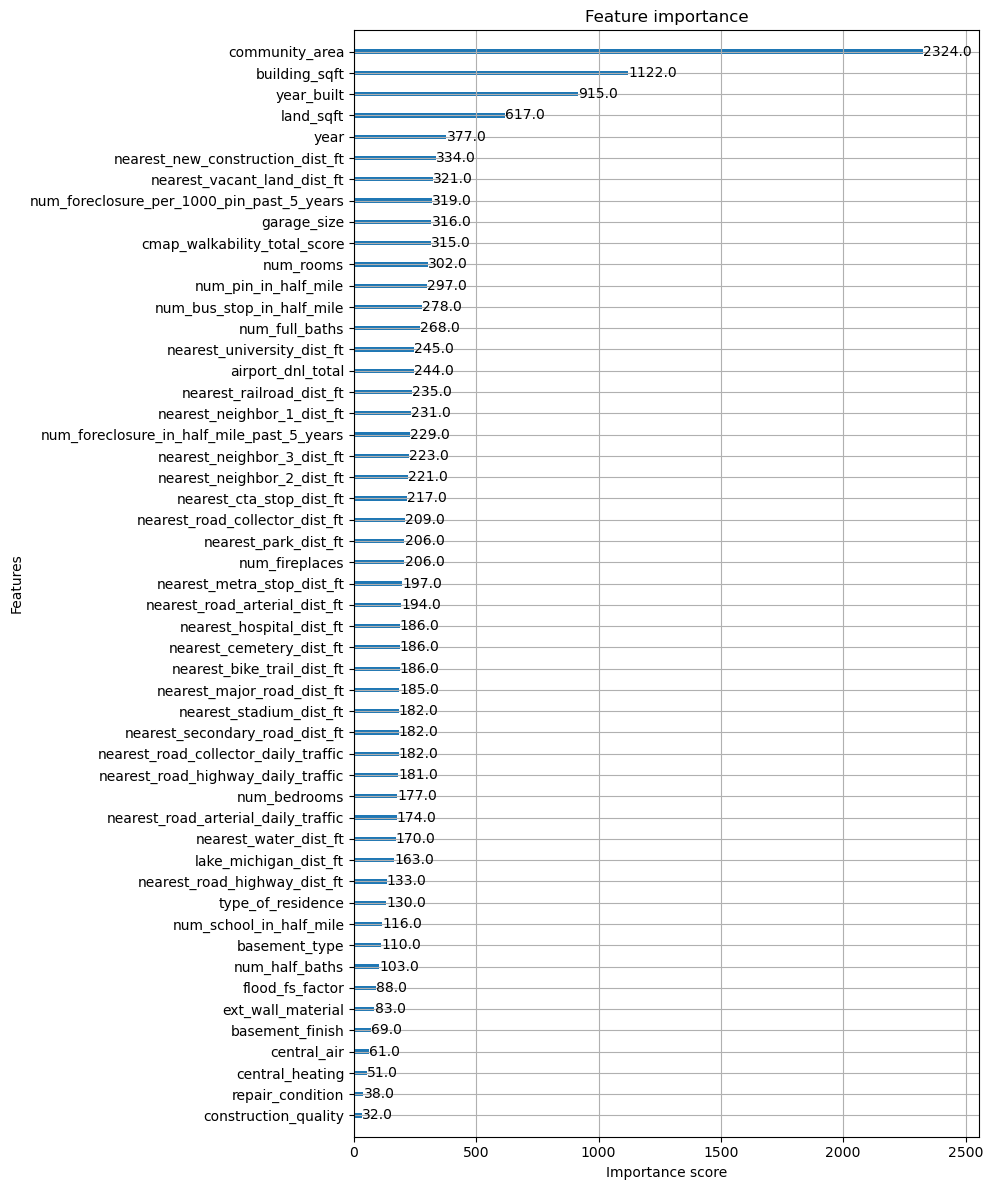

In [32]:
fig, ax = plt.subplots(figsize=(10, 12))  # wider and taller
xgb.plot_importance(model, ax=ax)
plt.tight_layout()
plt.show()

In [33]:
def categorical_pdp(model, X, feature, categories=None):
    """
    Compute partial dependence (marginal expected value) for a categorical feature.
    
    model: fitted XGBRegressor (enable_categorical=True)
    X: DataFrame used for prediction (same columns/dtypes as training)
    feature: name of the categorical column
    categories: optional list/order of categories to evaluate; defaults to all observed categories
    """
    if categories is None:
        categories = X[feature].cat.categories if hasattr(X[feature], "cat") else X[feature].unique()

    results = []
    X_temp = X.copy()

    for cat in categories:
        X_temp[feature] = cat
        # preserve categorical dtype/categories so xgboost doesn't complain
        X_temp[feature] = X_temp[feature].astype(X[feature].dtype)
        preds = model.predict(X_temp)
        results.append({"category": cat, "mean_prediction": preds.mean(), "std_prediction": preds.std()})

    return pd.DataFrame(results).sort_values("mean_prediction", ascending=False)

pdp_data = categorical_pdp(model, X, "community_area")
print(pdp_data.to_string(index=False))

 category  mean_prediction  std_prediction
        7    954914.750000   435343.968750
        6    859659.625000   412697.750000
        8    809031.125000   406005.968750
        5    795752.125000   391002.156250
       24    764630.437500   412807.343750
       77    716724.437500   358888.250000
       41    710008.937500   335681.437500
       33    694721.687500   328254.156250
       22    691049.875000   421144.593750
        3    659681.875000   352642.875000
        4    618871.187500   355727.187500
       14    563330.750000   484060.375000
       16    546695.000000   270766.718750
       21    545180.500000   268689.125000
       28    537610.937500   284769.000000
       12    495808.437500   226333.968750
       31    487490.031250   270407.250000
       34    487369.906250   179897.796875
       39    483599.250000   262554.562500
        9    483012.125000   209344.671875
       13    482924.562500   206131.671875
        2    480672.687500   195260.890625
        1  